# 02 · Design variables and constraints

Preliminary design is **not** 'minimise mass'. It is 'minimise mass *subject to* a wall of constraints': the aircraft must take off in the available field length, climb on one engine, reach its ceiling, and land slowly enough. Here we sweep the two classic first-order design variables — **wing loading** $W/S$ and **power-to-weight** $P/W$ — and watch feasibility, not just mass, decide the design.

In [1]:
# --- environment setup (educational tutorials) ---------------------------------
# These notebooks teach concepts *through* PhlyGreen. They use the real design API where
# it exists and small, clearly-labelled pedagogical proxies where it does not.
import warnings
warnings.filterwarnings("ignore")     # keep the solver's internal chatter out of the output
import numpy as np
import matplotlib.pyplot as plt

from _learning_utils import add_examples_to_path
add_examples_to_path()                # puts trunk/examples on sys.path (no absolute paths)

import PhlyGreen as pg
from PhlyGreen import postprocess as pp

from common import traditional_config
from _learning_utils import safe_design

base = traditional_config()
print('baseline configuration:', base.configuration)
print('design range          :', base.mission.range_mission, 'nm')

baseline configuration: Traditional
design range          : 750 nm


## 1. Sweep the wing loading $W/S$

`config.design_wing_loading` fixes $W/S$ [N/m²] instead of letting the constraint analysis pick it. For each value we resize the whole aircraft (power-to-weight follows from the binding constraint) and record take-off weight and block fuel. A low $W/S$ means a big wing (heavy, draggy); a high $W/S$ means a small wing (fast stall, hard landing, steep climb power).

In [2]:
ws_grid = np.linspace(2000, 5200, 17)     # wing loading [N/m^2]
wto, fuel, feas = [], [], []
for ws in ws_grid:
    cfg = traditional_config(); cfg.design_wing_loading = float(ws)
    res, ok, note = safe_design(cfg)
    feas.append(ok)
    wto.append(res.WTO if ok else np.nan)
    fuel.append(res.block_fuel if ok else np.nan)
wto, fuel = np.array(wto), np.array(fuel)
i_best = int(np.nanargmin(wto))
print(f'minimum-WTO wing loading ~ {ws_grid[i_best]:.0f} N/m^2  -> WTO {wto[i_best]:,.0f} kg')

minimum-WTO wing loading ~ 3000 N/m^2  -> WTO 17,981 kg


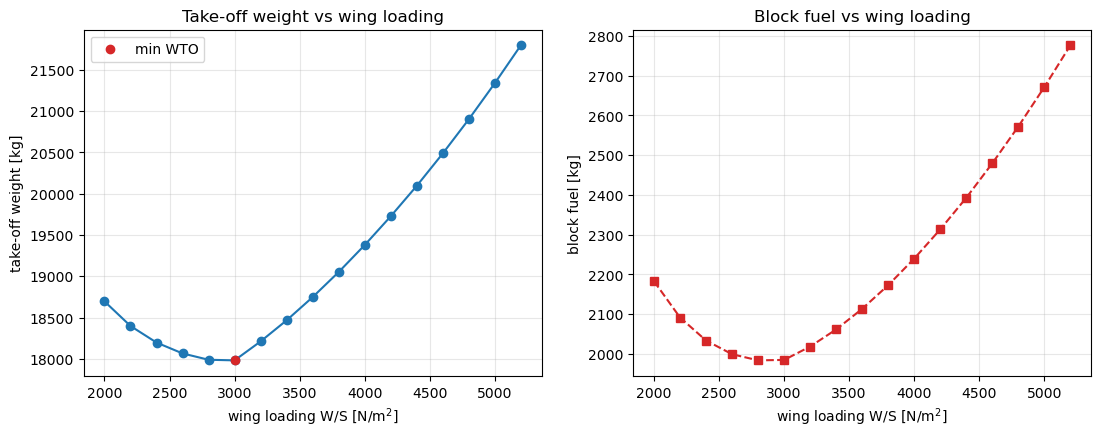

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
axL.plot(ws_grid, wto, 'o-', color='tab:blue')
axL.scatter([ws_grid[i_best]], [wto[i_best]], color='tab:red', zorder=5, label='min WTO')
axL.set_xlabel('wing loading W/S [N/m$^2$]'); axL.set_ylabel('take-off weight [kg]')
axL.set_title('Take-off weight vs wing loading'); axL.grid(alpha=0.3); axL.legend()
axR.plot(ws_grid, fuel, 's--', color='tab:red')
axR.set_xlabel('wing loading W/S [N/m$^2$]'); axR.set_ylabel('block fuel [kg]')
axR.set_title('Block fuel vs wing loading'); axR.grid(alpha=0.3)
plt.show()

There is a clear **interior optimum**: too small a wing loading wastes structure and wetted area; too large a wing loading raises induced drag at the constraint speeds and forces a bigger engine. But mass alone does *not* tell you which wing loadings are even *allowed* — for that we need the constraint diagram.

## 2. The real constraint diagram (PhlyGreen)

PhlyGreen's constraint analysis lives in the $(W/S,\,P/W)$ plane. Each requirement (take-off, one-engine-inoperative climb, ceiling, turn, landing…) draws a curve; the **feasible region is above/right of every curve**, and PhlyGreen picks the design point that minimises installed power. This is the formal version of the trade-off we just saw.

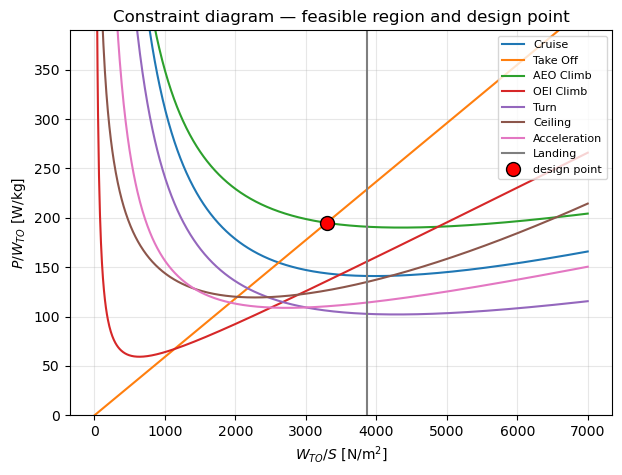

chosen design point: W/S = 3,294 N/m^2, P/W = 194.9 W/N


In [4]:
aircraft = pg.build_aircraft(); aircraft.configure(traditional_config())
ax = pp.plot_constraint_diagram(aircraft)
ax.set_title('Constraint diagram — feasible region and design point')
plt.show()
print(f'chosen design point: W/S = {aircraft.DesignWTOoS:,.0f} N/m^2, '
      f'P/W = {aircraft.DesignPW:,.1f} W/N')

## 3. A self-contained feasibility map (pedagogical proxy)

> ⚠️ **Teaching proxy, drawn by hand — but using PhlyGreen's *exact* landing equation so it stays consistent with the diagram above.** To make the idea of a feasible region concrete, we draw two constraints:
> - a **landing / stall ceiling** on $W/S$: $W/S \le \tfrac12\,\rho(h)\,C_{L,max}\,V_{ref}^2$. This is *literally* PhlyGreen's `Performance.Landing` formula, evaluated with the same ISA density at the landing altitude, the same $C_{L,max}$, and the 59 m/s reference speed from `examples/common.py` — so the toy ceiling **matches the landing curve in the constraint diagram above** (~3860 N/m²), and the design point sits safely below it.
> - a **climb power floor** on $P/W$ — this one is *illustrative only* (a single straight line), standing in for the family of take-off / climb curves that the real constraint analysis computes.

The shaded corner is the 'feasible' region. The real constraint analysis (section 2) has many more curves and proper aerodynamics — but the *shape of the argument* is identical.

landing ceiling W/S = 3,861 N/m^2   (PhlyGreen landing curve = 3,861 N/m^2)


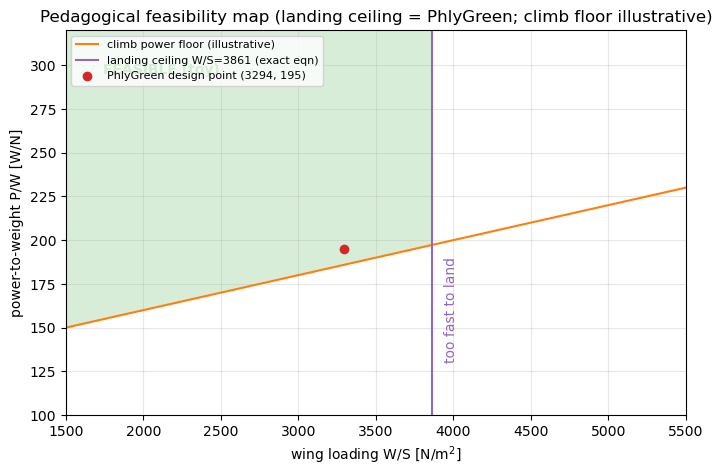

In [5]:
import PhlyGreen.Utilities.Atmosphere as ISA

# Landing ceiling — PhlyGreen's *exact* equation (see Performance.Landing):
#     W/S_max = rho(h)/2 * CLmax * V_ref^2
# Using the same inputs as the constraint analysis guarantees the toy ceiling matches the
# landing curve in the diagram above (no spurious safety factors).
alt_land = 500.0                                    # landing altitude [m] (examples/common.py)
rho      = ISA.atmosphere.RHOstd(alt_land, 0.0)     # ISA density at 500 m [kg/m^3]
CLmax    = aircraft.aerodynamics.ClMax              # landing CLmax (= 1.9)
V_ref    = 59.0                                     # approach/stall reference speed [m/s TAS]
WS_landing_max = 0.5 * rho * CLmax * V_ref**2       # [N/m^2]  -> ~3860, matches PhlyGreen
print(f'landing ceiling W/S = {WS_landing_max:,.0f} N/m^2   '
      f'(PhlyGreen landing curve = {aircraft.constraint.WTOoSLanding[0]:,.0f} N/m^2)')

# Climb power floor — ILLUSTRATIVE ONLY: a single line standing in for the climb/take-off curves.
WS = np.linspace(1500, 5500, 200)
PW_climb_floor = 120 + 0.02 * WS                    # [W/N], illustrative only

fig, ax = plt.subplots(figsize=(8, 5))
PW = np.linspace(100, 320, 200)
WSg, PWg = np.meshgrid(WS, PW)
feasible = (WSg <= WS_landing_max) & (PWg >= (120 + 0.02 * WSg))
ax.contourf(WSg, PWg, feasible, levels=[0.5, 1.5], colors=['tab:green'], alpha=0.18)
ax.plot(WS, PW_climb_floor, color='tab:orange', label='climb power floor (illustrative)')
ax.axvline(WS_landing_max, color='tab:purple', label=f'landing ceiling W/S={WS_landing_max:.0f} (exact eqn)')
ax.scatter([aircraft.DesignWTOoS], [aircraft.DesignPW], color='tab:red', zorder=5,
           label=f'PhlyGreen design point ({aircraft.DesignWTOoS:.0f}, {aircraft.DesignPW:.0f})')
ax.text(WS_landing_max*0.45, 295, 'FEASIBLE (toy)', color='tab:green', fontweight='bold')
ax.text(WS_landing_max*1.02, 130, 'too fast to land', color='tab:purple', rotation=90, va='bottom')
ax.set_xlabel('wing loading W/S [N/m$^2$]'); ax.set_ylabel('power-to-weight P/W [W/N]')
ax.set_title('Pedagogical feasibility map (landing ceiling = PhlyGreen; climb floor illustrative)')
ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=8)
plt.show()

The minimum-mass wing loading from step 1 only matters **if it lies inside the feasible region**. Push $W/S$ past the landing ceiling and the aircraft is simply not certifiable, no matter how light it looks.

## Key takeaways

1. $W/S$ and $P/W$ are the two dominant first-order design variables; both have *opposing* effects on different metrics, so an interior optimum exists.
2. A **design constraint** is a hard requirement (field length, climb gradient, landing speed) that bounds the design space — independently of any objective.
3. **Minimum mass is not a valid objective on its own**: the lightest design is often infeasible. You minimise *within* the feasible region.

## Questions for students

1. Why does increasing wing loading *help* some metrics (structure, wetted area) and *hurt* others (stall speed, induced drag, climb power)?
2. In your own words, what is a *design constraint*, and how does it differ from a design *objective*?
3. Why is 'minimum take-off mass' not always a valid design goal? Give a concrete case where the minimum-mass point is infeasible.

## Suggested modifications

- Tighten the take-off field length in `examples/common.py` (`'sTO'`) and re-plot the constraint diagram — watch the feasible region shrink.
- Change `CLmax` or `V_ref` in the toy map and see the landing ceiling move (and check it still matches PhlyGreen's landing curve).
- Sweep design range as a *third* variable and see how the optimum $W/S$ drifts.
- Overlay the swept WTO minimum on the constraint diagram — does it sit on a binding constraint?

---
*These tutorials are educational. Where the full PhlyGreen capability is not exposed (formal constraint feasibility, non-CO₂ climate weighting) the notebook uses a simplified, clearly-labelled proxy — read the comments before trusting any number.*